# MOSAIQ: Exploring the ISD subset

This notebook demonstrates loading and inspecting the MOSAIQ Frictionless data package for the ISD subset.

It shows how to:
- Load the data package via the Frictionless Python API
- Read clip-level and dataset-level CSVs into pandas
- Visualise the soundscape circumplex
- Programmatically validate the package


In [1]:
from frictionless import Package, validate
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load the data package

In [2]:
package = Package("../datapackage.yaml")
print(f"Package: {package.name}")
print(f"Title:   {package.title}")
print(f"Version: {package.version}")
print(f"Resources: {[r.name for r in package.resources]}")

Package: mosaiq
Title:   MOSAIQ – Multimodal Open Soundscape AI Quality-benchmark
Version: 0.1.0
Resources: ['datasets', 'clips', 'responses']


## 2. Dataset-level catalogue (20 datasets)

In [3]:
datasets = pd.read_csv("../data/catalogue/datasets.csv")
print(f"Datasets: {len(datasets)}")
datasets[["dataset_name", "year", "scenario", "n_participants"]].head(10)

Datasets: 20


,dataset_name,year,scenario,n_participants
0,International Soundscape Database (ISD),2022.0,Urban,3500.0
1,Affective Responses to Augmented Urban Soundsc...,2024.0,Urban,642.0
2,Athens Urban Soundscape (ATHUS),2019.0,Urban,10.0
3,IADS-2,2007.0,Various,716.0
4,IADS-E,2018.0,Various,207.0
5,Emo-soundscapes,2017.0,Various,1182.0
6,HSDD,NaN,Indoor,105.0
7,DeLTA,2022.0,Urban,1221.0
8,SATP,2022.0,Urban,645.0
9,Hong et al.'s dataset,2021.0,Urban,33.0


## 3. Distribution of perceptual frameworks

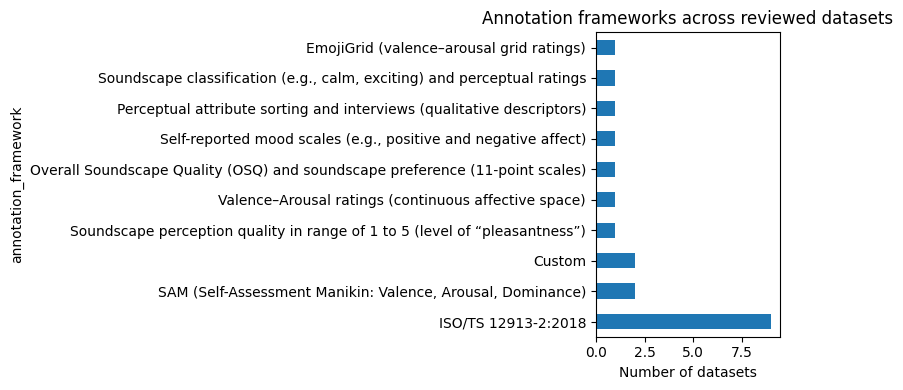

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
datasets["annotation_framework"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Annotation frameworks across reviewed datasets")
ax.set_xlabel("Number of datasets")
plt.tight_layout()
plt.show()

## 4. Load ISD clip-level data

In [5]:
clips = pd.read_csv("../data/ISD/clips.csv")
print(f"ISD clips: {len(clips)}")
clips.head()

ISD clips: 2709


,clip_id,dataset_id,LocationID,SessionID,GroupID,latitude,longitude,binaural_start_s,binaural_end_s,audio_asset,...,mean_PAQ7_uneventful,mean_PAQ8_calm,mean_ISOPleasant,mean_ISOEventful,LAeq_dBA,loudness_N_sone,sharpness_S_acum,roughness_R_asper,fluctuation_strength_F_vacil,tonality_T_tu
0,ISD_CamdenTown_CamdenTown1_CT101,ISD,CamdenTown,CamdenTown1,CT101,51.539124,-0.142624,0.0,31.57,ISD_CamdenTown_CT101_binaural,...,1.667,1.333,-0.2298,0.2846,69.93,30.8,2.09,0.0363,0.01770,0.304
1,ISD_CamdenTown_CamdenTown1_CT102,ISD,CamdenTown,CamdenTown1,CT102,51.539124,-0.142624,0.0,32.47,ISD_CamdenTown_CT102_binaural,...,5.000,5.000,0.1036,-0.7500,70.60,33.2,2.14,0.0430,0.01760,0.252
2,ISD_CamdenTown_CamdenTown1_CT103,ISD,CamdenTown,CamdenTown1,CT103,51.539124,-0.142624,0.0,35.16,ISD_CamdenTown_CT103_binaural,...,1.000,2.000,0.2500,0.7500,66.36,24.6,1.98,0.0367,0.00858,0.184
3,ISD_CamdenTown_CamdenTown1_CT104,ISD,CamdenTown,CamdenTown1,CT104,51.539124,-0.142624,0.0,31.96,ISD_CamdenTown_CT104_binaural,...,1.000,2.000,0.0732,0.6768,72.40,38.6,2.37,0.0416,0.01470,0.202
4,ISD_CamdenTown_CamdenTown1_CT105,ISD,CamdenTown,CamdenTown1,CT105,51.539124,-0.142624,0.0,NaN,ISD_CamdenTown_CT105_binaural,...,3.500,3.500,0.1616,-0.0152,NaN,NaN,NaN,NaN,NaN,NaN


## 5. ISD soundscape circumplex

Each point is one clip's mean perceptual rating, projected onto the
ISO Pleasant–Eventful circumplex


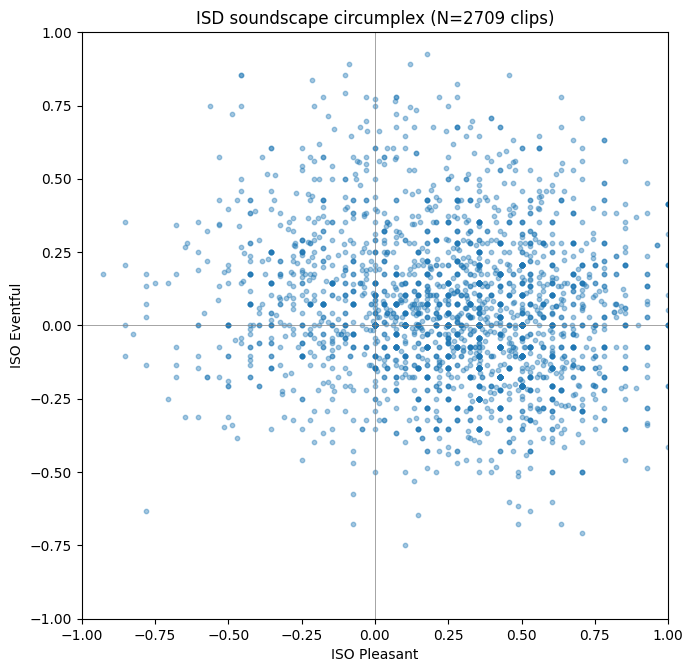

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(clips["mean_ISOPleasant"], clips["mean_ISOEventful"],
           alpha=0.4, s=10)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel("ISO Pleasant")
ax.set_ylabel("ISO Eventful")
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_aspect("equal")
ax.set_title(f"ISD soundscape circumplex (N={len(clips)} clips)")
plt.tight_layout()
plt.show()

## 6. Sound level vs perceived pleasantness

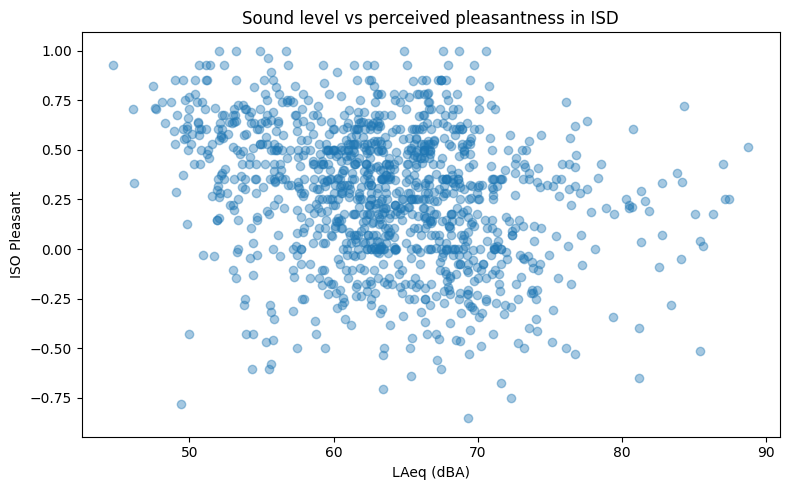

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(clips["LAeq_dBA"], clips["mean_ISOPleasant"], alpha=0.4)
ax.set_xlabel("LAeq (dBA)")
ax.set_ylabel("ISO Pleasant")
ax.set_title("Sound level vs perceived pleasantness in ISD")
plt.tight_layout()
plt.show()

## 7. Programmatic validation

In [8]:
report = validate("../datapackage.yaml")
print(f"Valid: {report.valid}")
print(f"Tasks validated: {len(report.tasks)}")
for task in report.tasks:
    print(f"  - {task.name}: {'VALID' if task.valid else 'INVALID'}")

Valid: True
Tasks validated: 3
  - datasets: VALID
  - clips: VALID
  - responses: VALID
